In [1]:
import os
import kagglehub
import shutil

path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
print("Fichiers téléchargés dans :", path)

# Dossier de destination
dest = "data"
#os.makedirs(dest, exist_ok=True)

# Copier tous les fichiers du dossier téléchargé vers /data
#for fichier in os.listdir(path):
#    src_file = os.path.join(path, fichier)
#    dst_file = os.path.join(dest, fichier)
#    shutil.copy2(src_file, dst_file)

print("Fichiers copiés dans :", dest)

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fichiers téléchargés dans : /home/onyxia/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques
Fichiers copiés dans : data


In [2]:
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')

In [3]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
df_train.isna().sum().sort_values(ascending=False).head(25)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
BldgType           0
Neighborhood       0
LandSlope          0
LotConfig          0
Condition1         0
dtype: int64

In [5]:
df_train.select_dtypes(exclude=['bool','object']).isna().sum().sort_values(ascending=False)

LotFrontage      259
GarageYrBlt       81
MasVnrArea         8
LotArea            0
MSSubClass         0
Id                 0
OverallCond        0
OverallQual        0
YearRemodAdd       0
YearBuilt          0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
BsmtFinSF1         0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
1stFlrSF           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

In [6]:
df_train[['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu']].describe()

,PoolQC,MiscFeature,Alley,Fence,MasVnrType,FireplaceQu
count,7,54,91,281,588,770
unique,3,4,2,4,3,5
top,Gd,Shed,Grvl,MnPrv,BrkFace,Gd
freq,3,49,50,157,445,380


In [7]:
cat_cols = df_train.select_dtypes(exclude='number').columns
df_train[cat_cols] = df_train[cat_cols].fillna('None')

In [8]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


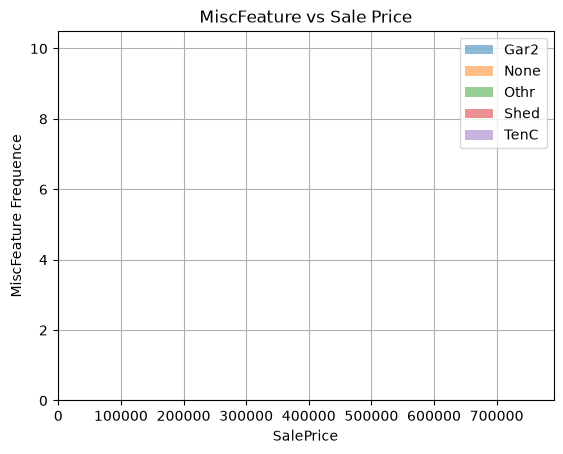

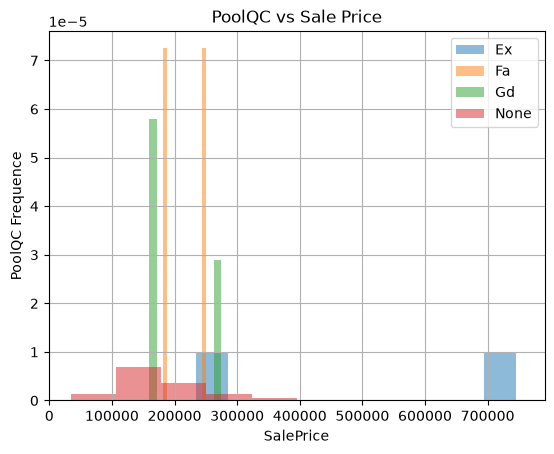

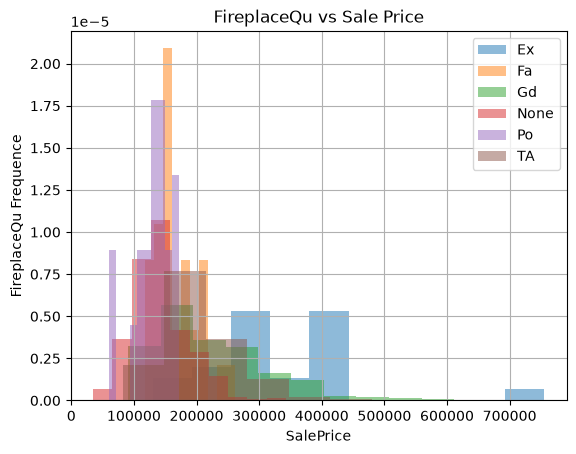

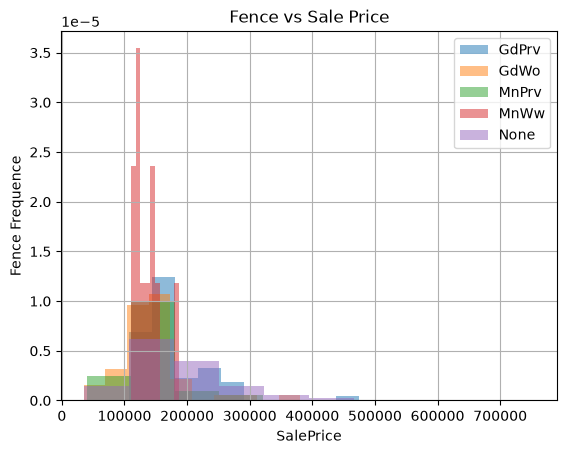

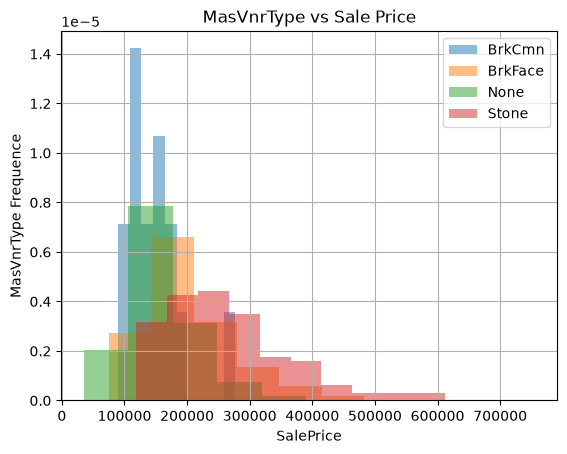

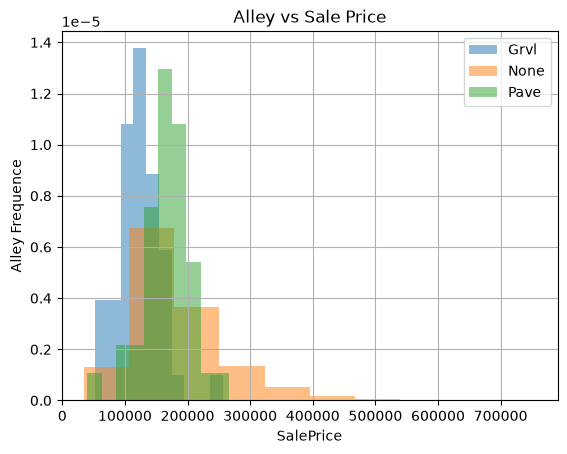

In [9]:
Category={'PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu'}
for cat in Category:
    fig, ax = plt.subplots()
    for name, group in df_train.groupby(cat)['SalePrice']:
        group.hist(alpha=0.5, label=name, ax=ax,density=True)
    ax.set_title(f'{cat} vs Sale Price')
    ax.set_xlabel('SalePrice')
    ax.set_ylabel(f'{cat} Frequence')
    ax.legend()
    plt.show()

In [10]:
Category={'PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu'}
for cat in Category:
    mean_na = df_train[df_train[cat]=='None']['SalePrice'].mean()
    mean_not_na = df_train[df_train[cat]!='None']['SalePrice'].mean()
    print(f'{cat} — None: {mean_na:.0f} | Non-NoNe: {mean_not_na:.0f}')

MiscFeature — None: 182046 | Non-NoNe: 151624
PoolQC — None: 180405 | Non-NoNe: 288139
FireplaceQu — None: 141331 | Non-NoNe: 216398
Fence — None: 187597 | Non-NoNe: 152912
MasVnrType — None: 156958 | Non-NoNe: 216458
Alley — None: 183452 | Non-NoNe: 142846


In [11]:
df_train['Pool']=(df_train['PoolArea']>0).astype(float)

<Axes: xlabel='PoolArea', ylabel='SalePrice'>

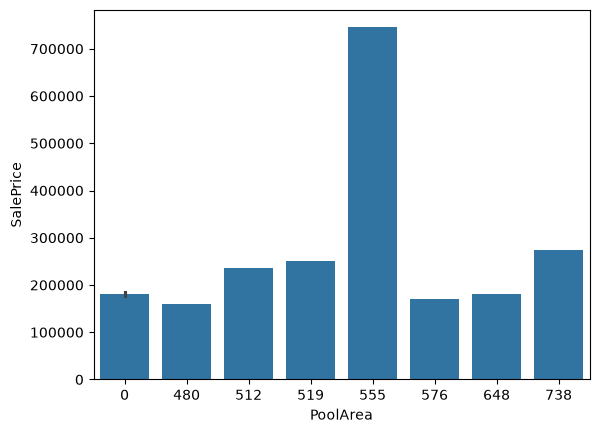

In [12]:
sns.barplot(data=df_train,x='PoolArea',y='SalePrice')

On peut sûrement drop PoolArea qui apporte pas bcp d'informations

<Axes: >

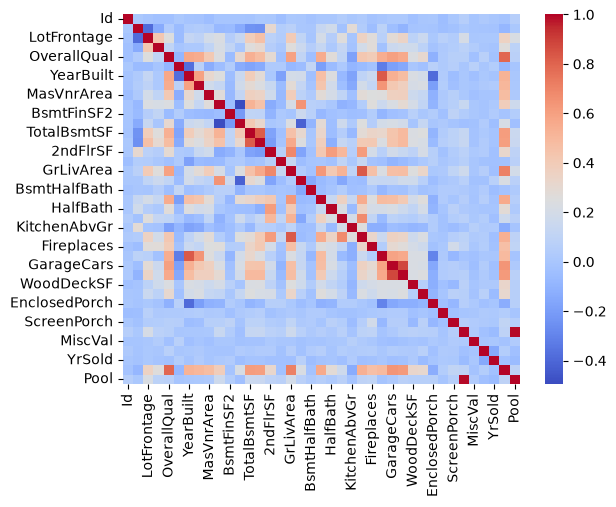

In [13]:
corr=df_train.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm')

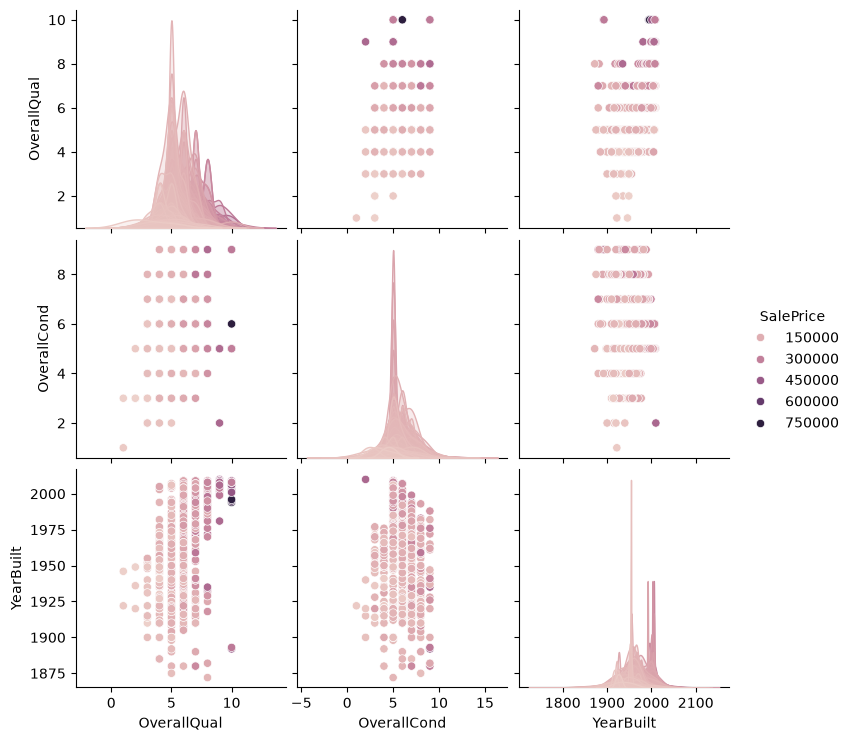

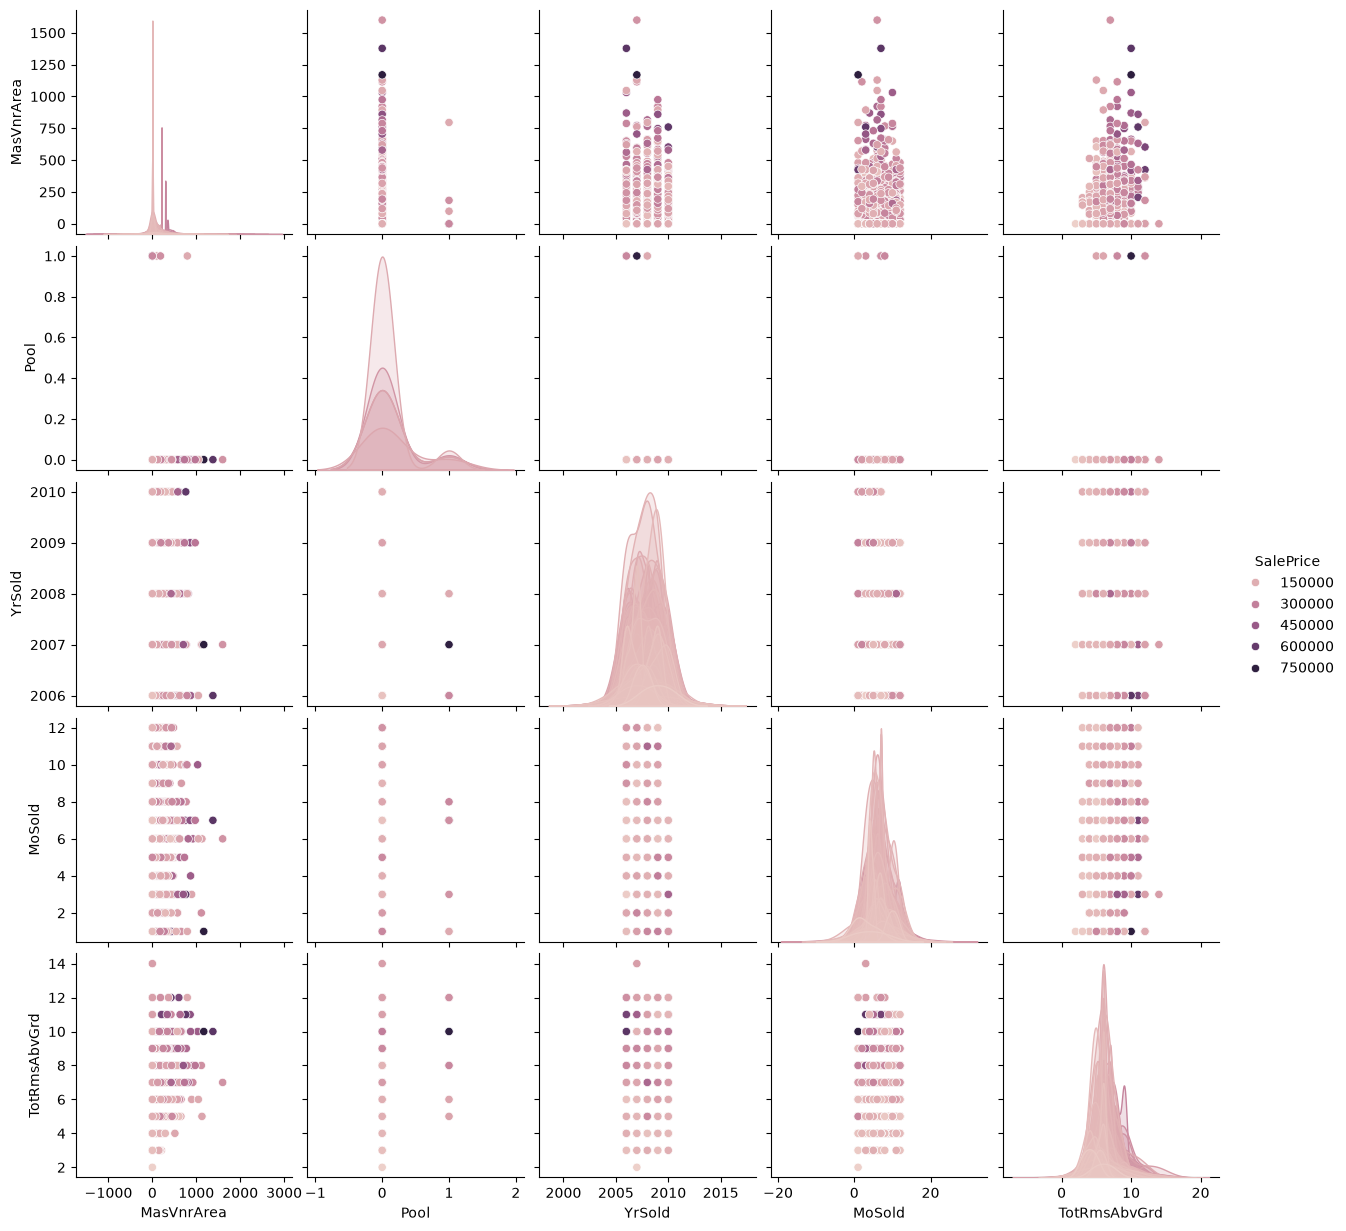

In [14]:
sns.pairplot(df_train[['Neighborhood', 'OverallQual', 'OverallCond', 'YearBuilt','SalePrice']], hue='SalePrice' )
sns.pairplot(df_train[['MasVnrArea','Pool','YrSold','MoSold','TotRmsAbvGrd','SalePrice']], hue='SalePrice' )
plt.show()


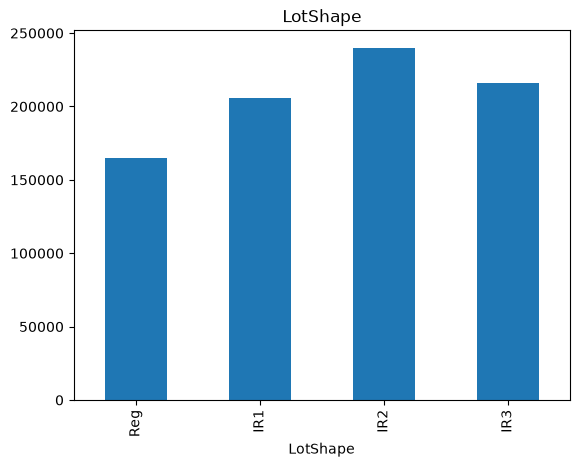

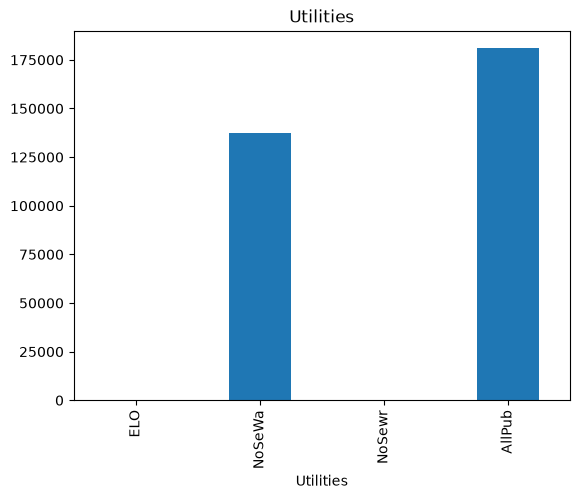

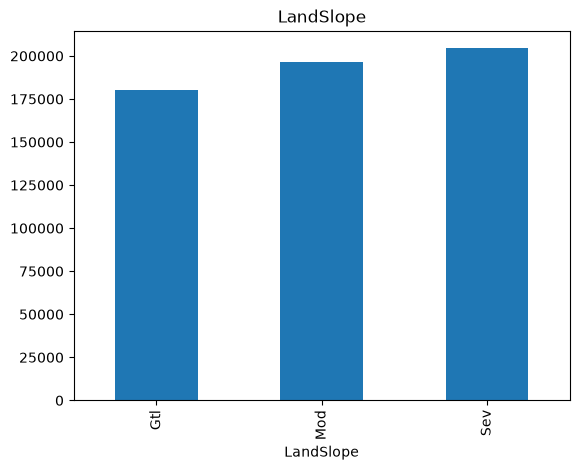

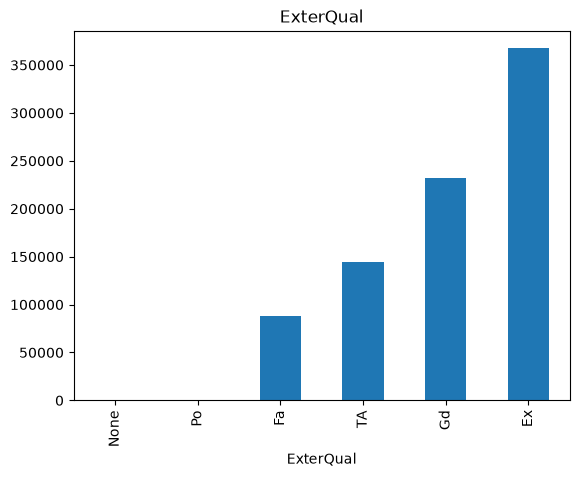

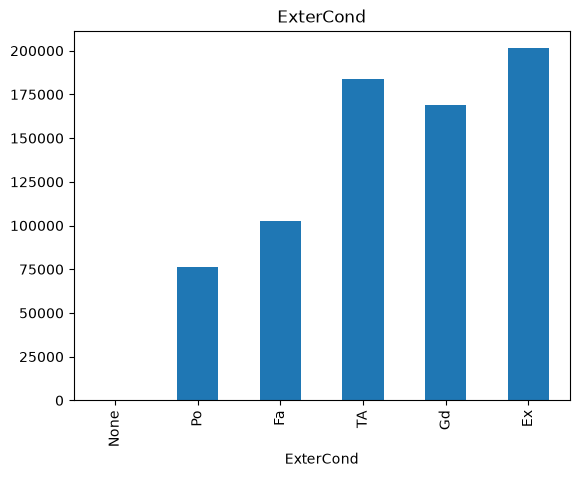

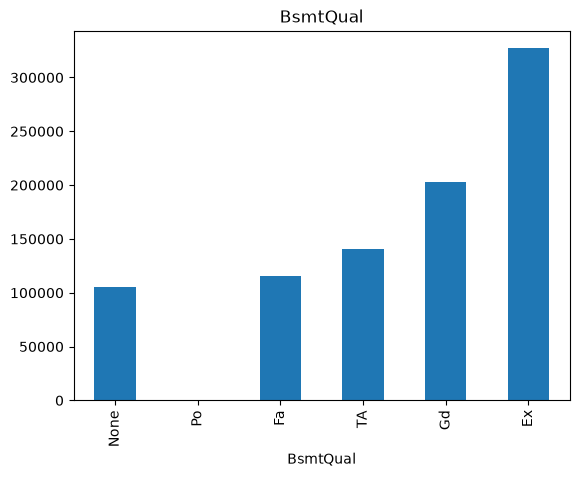

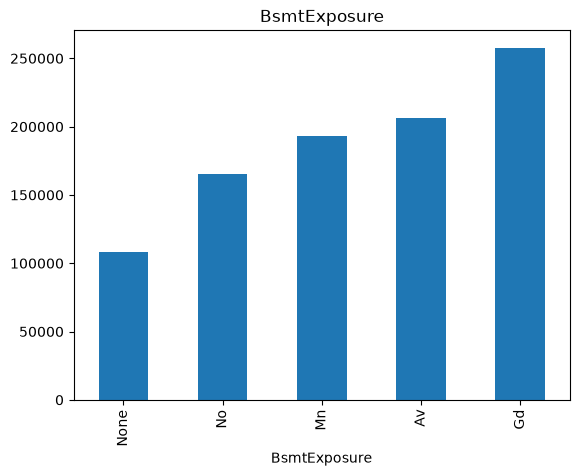

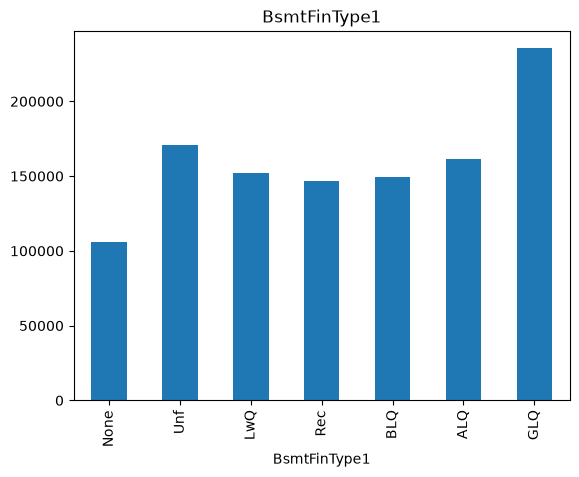

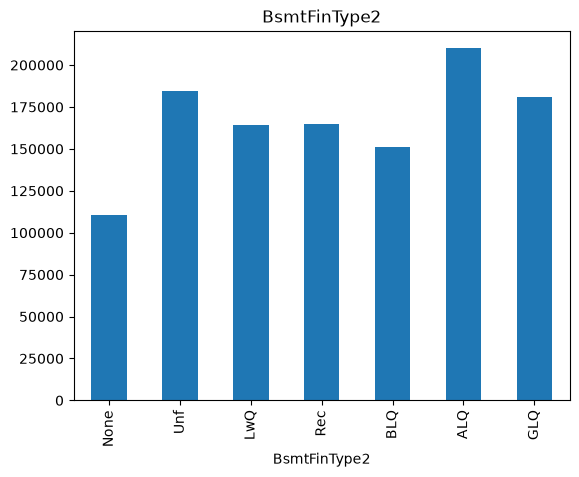

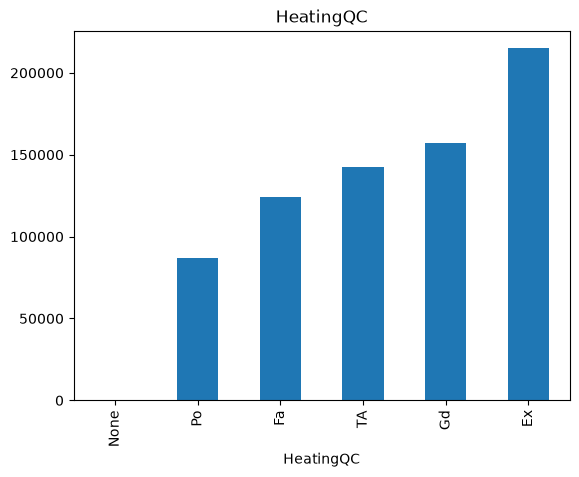

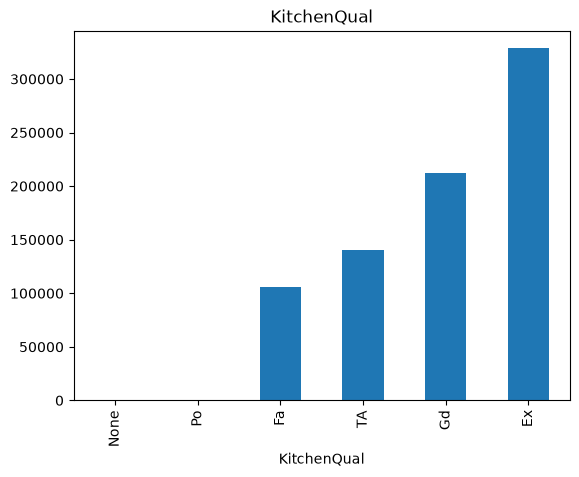

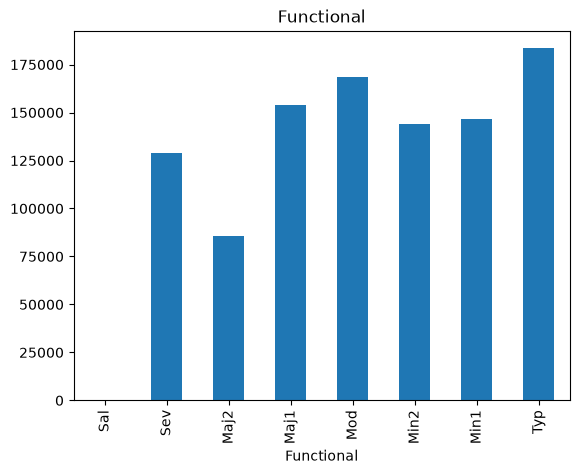

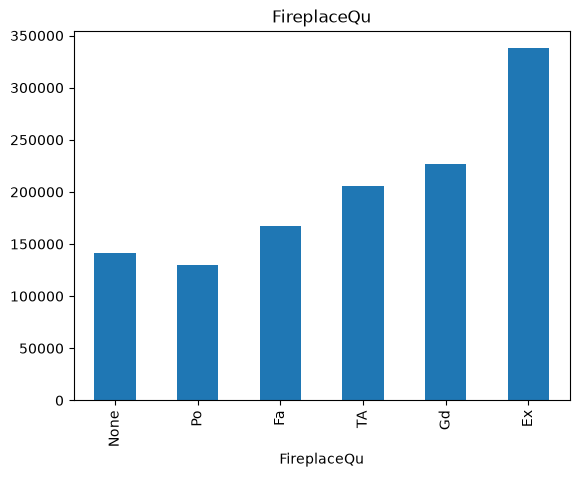

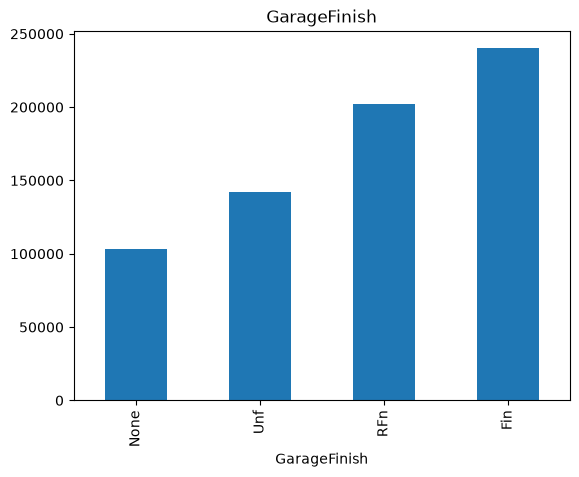

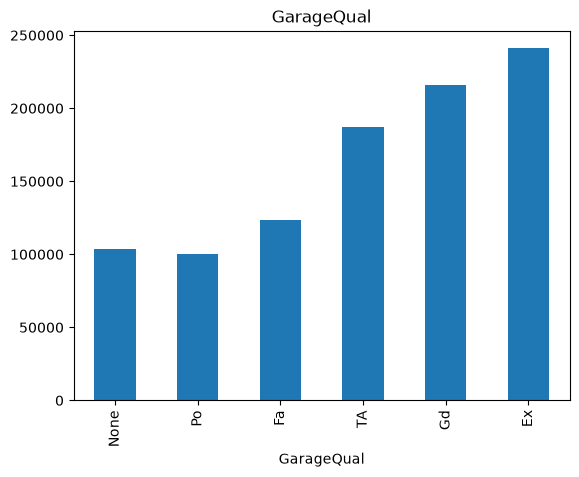

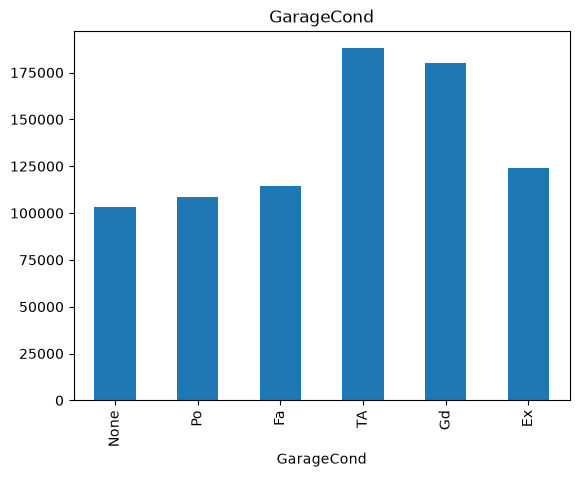

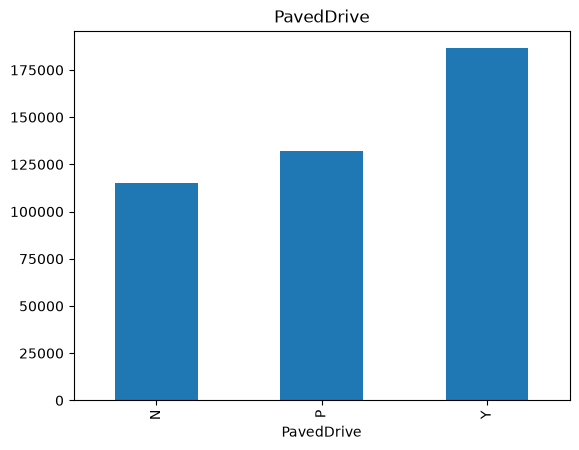

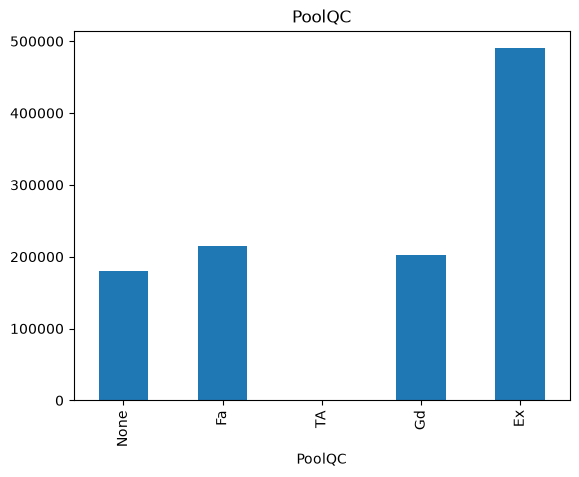

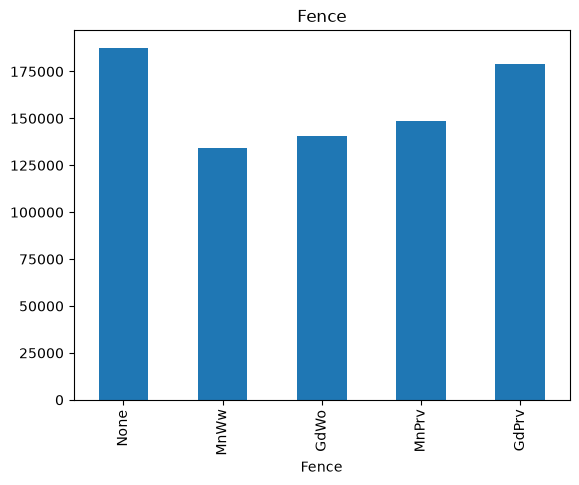

In [15]:
#Test soupçon d'ordinalité dans certaines catégories:

# Échelle de qualité générique (revient sur 6 colonnes)
qual_scale = ['Po', 'Fa', 'TA', 'Gd', 'Ex']

# Variantes avec "pas d'objet" (NA) en plus, à placer selon ton choix
# (toi tu as déjà remplacé les NA par 'None' plus tôt dans la conversation)
qual_scale_with_none = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

# PoolQC n'a pas de modalité 'Po' dans le fichier
poolqc_scale = ['None', 'Fa', 'TA', 'Gd', 'Ex']

ordinal_scales = {
    'ExterQual':    qual_scale_with_none,   # pas de NA en réalité, mais safe
    'ExterCond':    qual_scale_with_none,
    'HeatingQC':    qual_scale_with_none,
    'KitchenQual':  qual_scale_with_none,
    'BsmtQual':     qual_scale_with_none,   # NA = No Basement
    'GarageQual':   qual_scale_with_none,   # NA = No Garage
    'GarageCond':   qual_scale_with_none,   # NA = No Garage
    'FireplaceQu':  qual_scale_with_none,   # NA = No Fireplace
    'PoolQC':       poolqc_scale,           # NA = No Pool, pas de 'Po'

    'BsmtExposure': ['None', 'No', 'Mn', 'Av', 'Gd'],           # NA = No Basement
    'BsmtFinType1': ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],  # NA = No Basement
    'BsmtFinType2': ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],

    'GarageFinish': ['None', 'Unf', 'RFn', 'Fin'],              # NA = No Garage

    'LotShape':     ['Reg', 'IR1', 'IR2', 'IR3'],
    'LandSlope':    ['Gtl', 'Mod', 'Sev'],
    'Utilities':    ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    'PavedDrive':   ['N', 'P', 'Y'],

    'Functional':   ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],

    'Fence':        ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],  # ordre discutable, cf. remarque
}

cat_ord=['LotShape','Utilities','LandSlope','ExterQual','ExterCond','BsmtQual','BsmtExposure','BsmtFinType1','BsmtFinType2','HeatingQC','KitchenQual','Functional','FireplaceQu','GarageFinish','GarageQual','GarageCond','PavedDrive','PoolQC','Fence']

for c in cat_ord:
    means = df_train.groupby(c)['SalePrice'].mean()
    means = means.reindex(ordinal_scales[c])
    means.plot(kind='bar')
    plt.title(c)
    plt.show()

In [16]:
#On peut dire qu'il y a bien une notion d'ordinalité, donc quand on va passer en numérique plutôt qu'en catégorie, on va pas dummiser

In [17]:
reste_col=df_train.select_dtypes(exclude='number').columns.drop(list(ordinal_scales.keys()))
df_train = pd.get_dummies(df_train, columns=reste_col, drop_first=True)

In [18]:
from sklearn.preprocessing import PowerTransformer

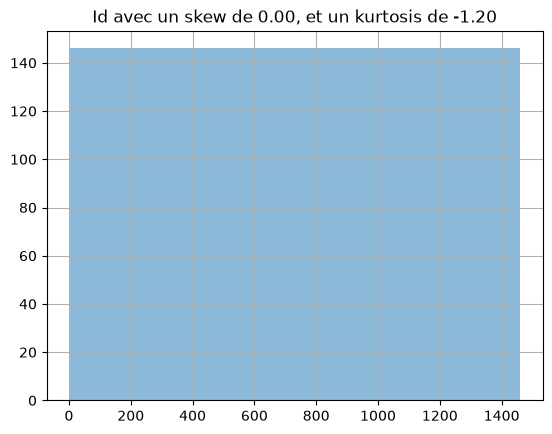

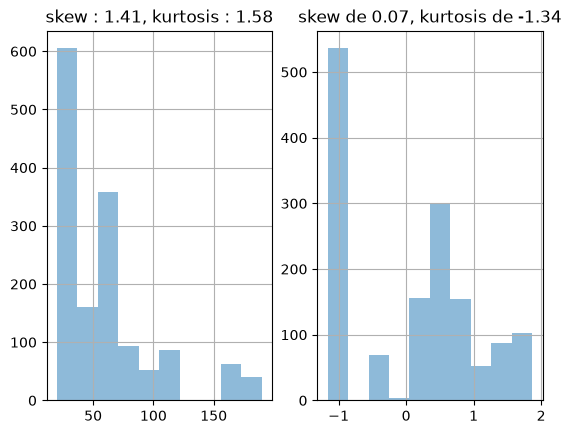

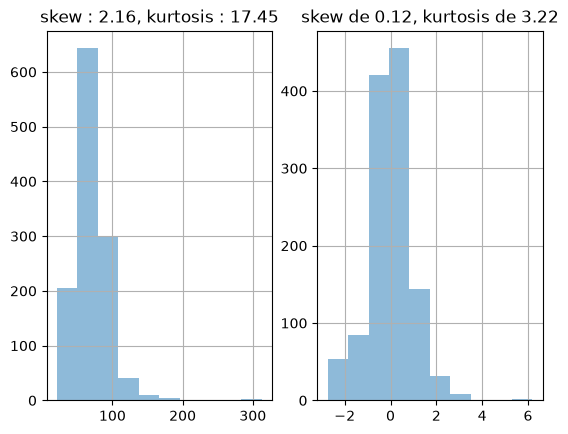

Skew trop élevé, à vérifier :LotArea


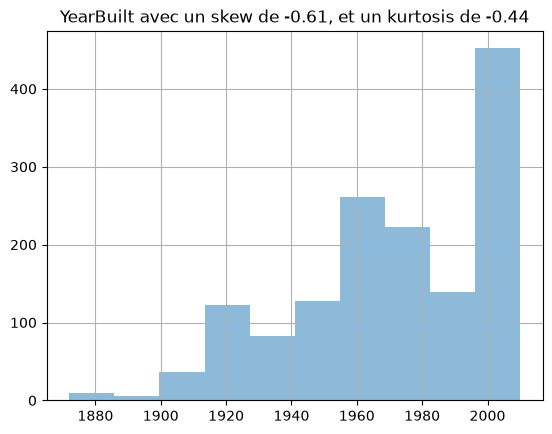

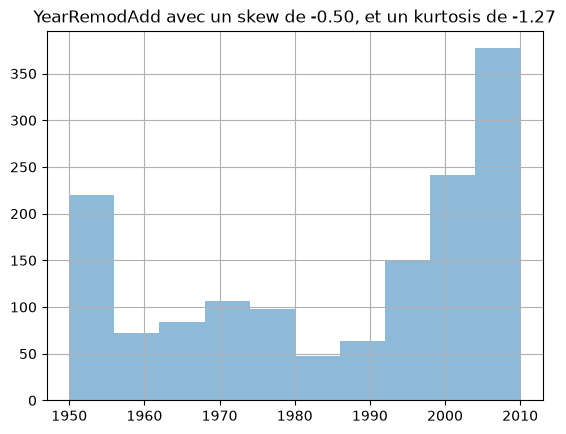

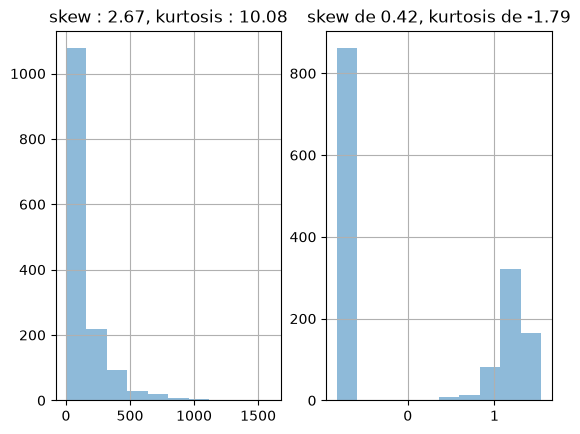

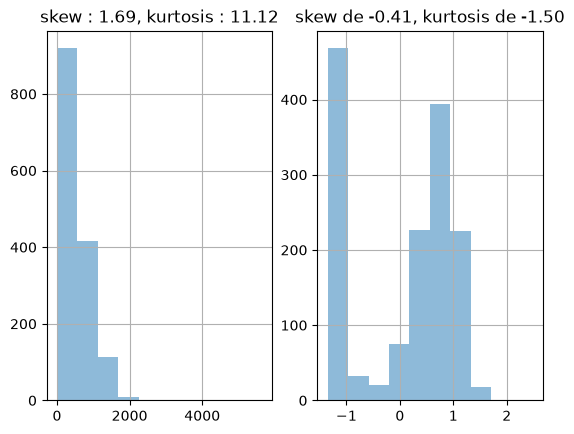

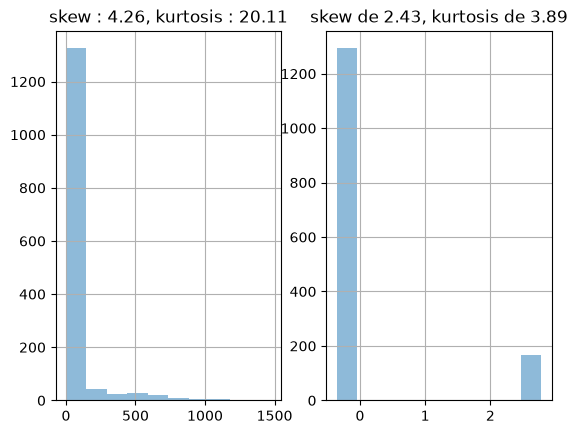

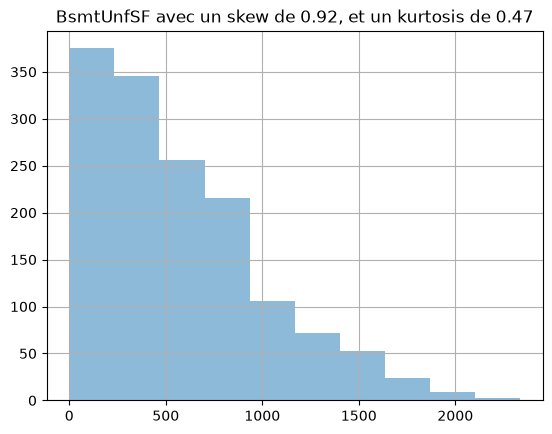

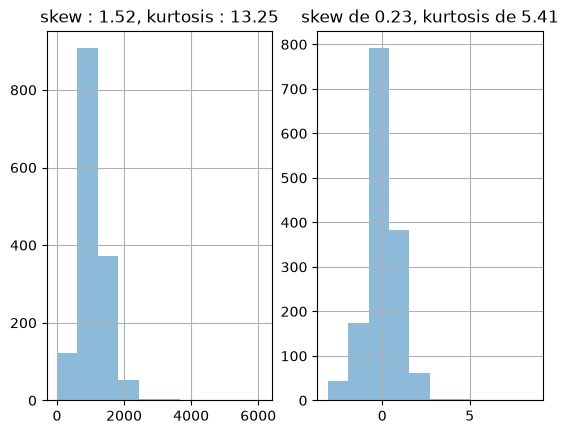

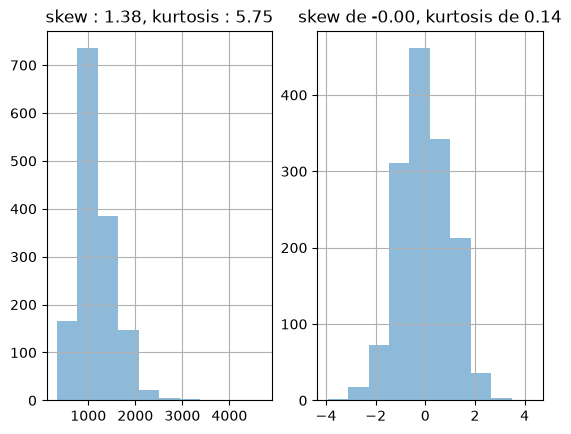

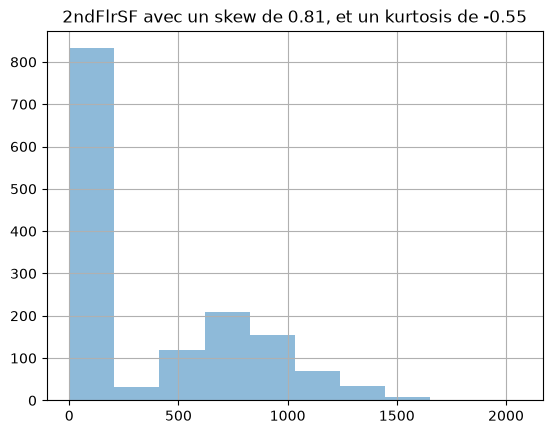

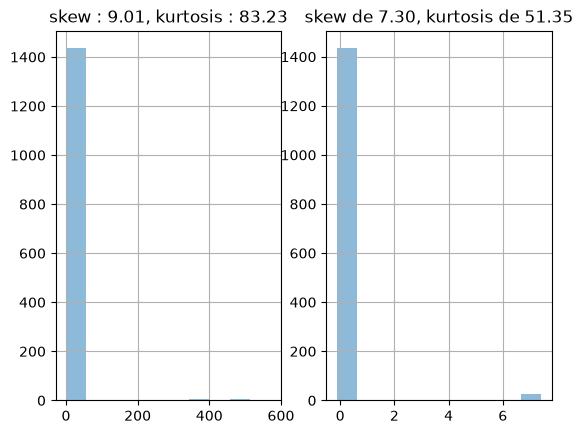

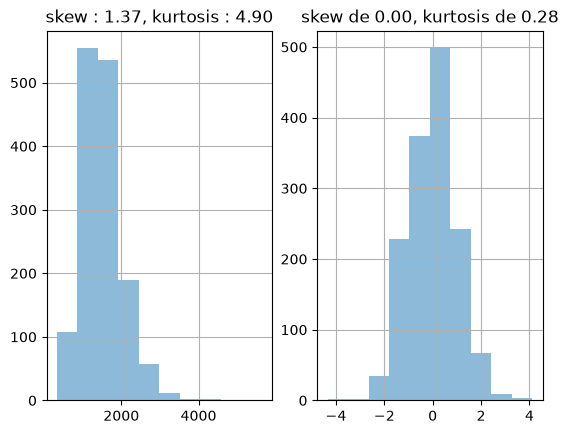

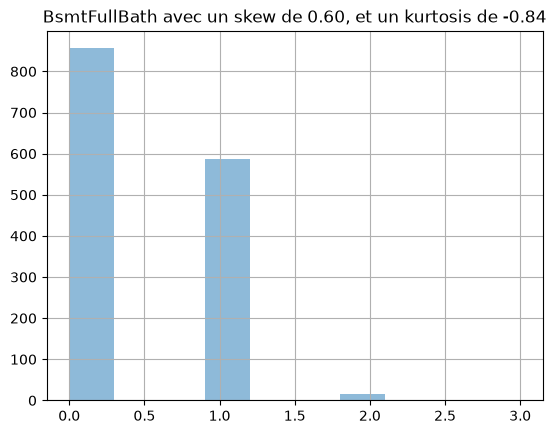

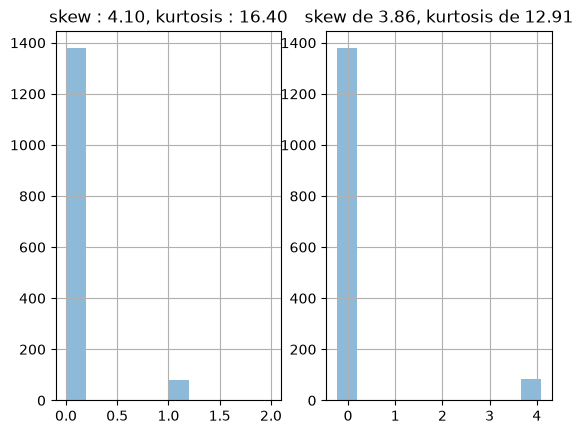

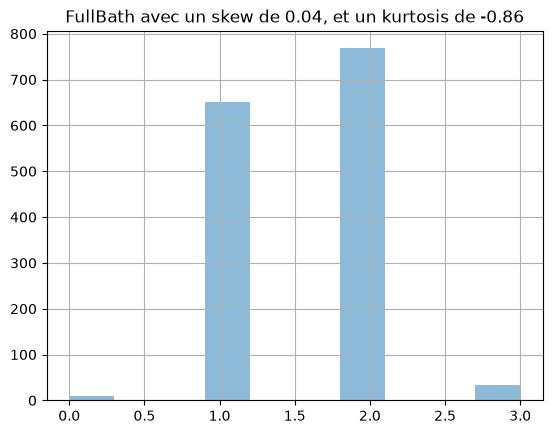

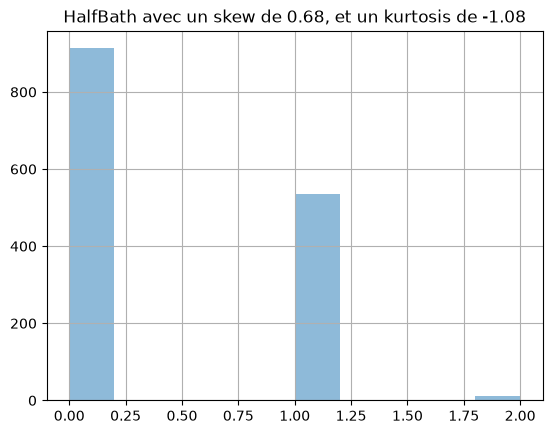

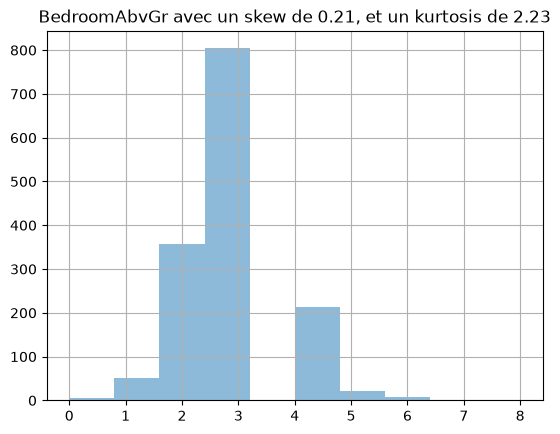

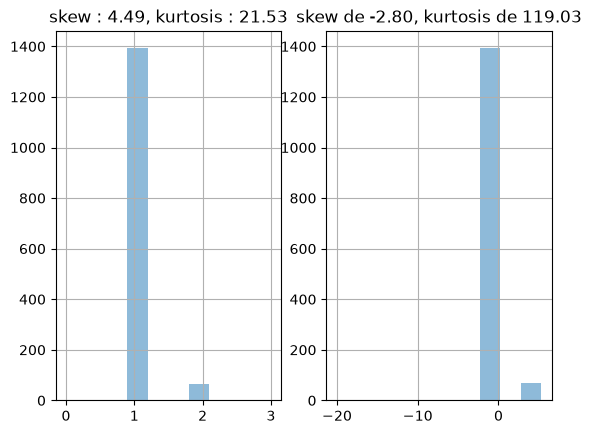

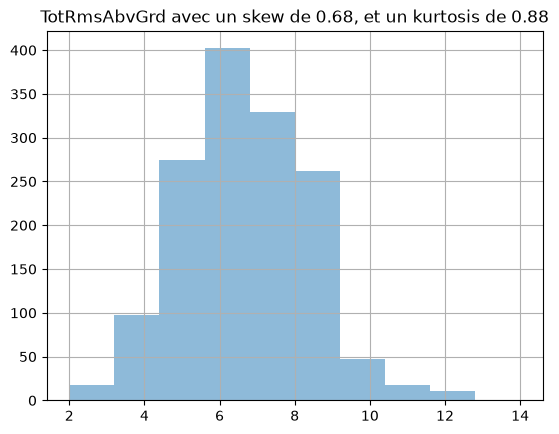

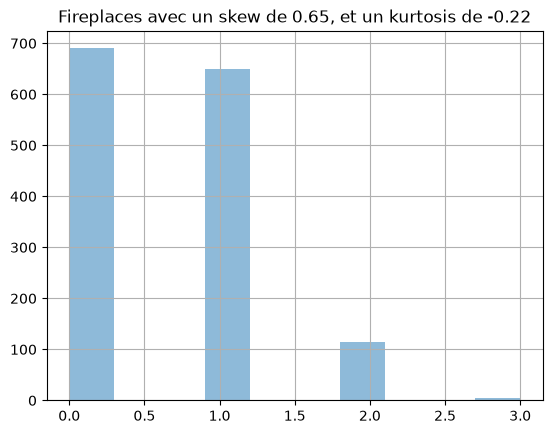

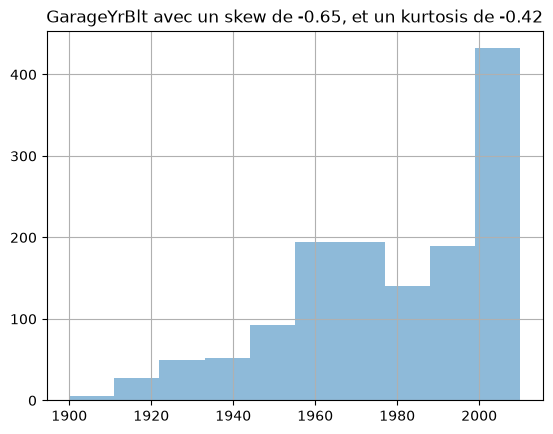

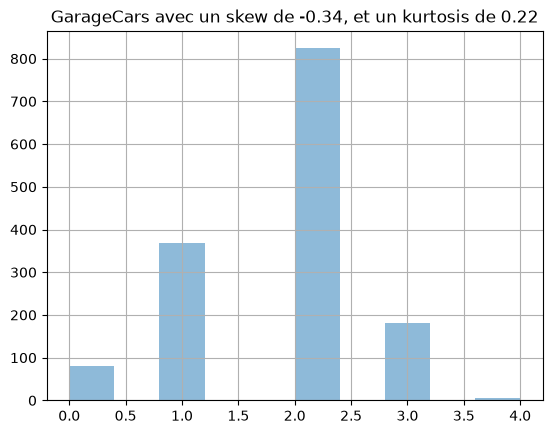

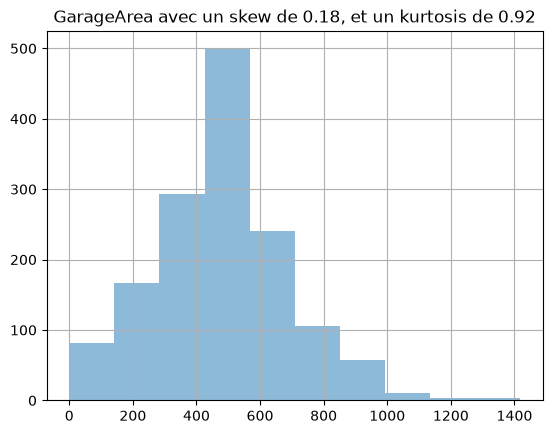

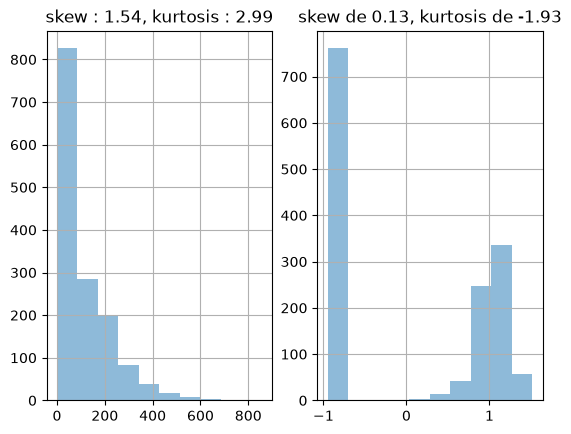

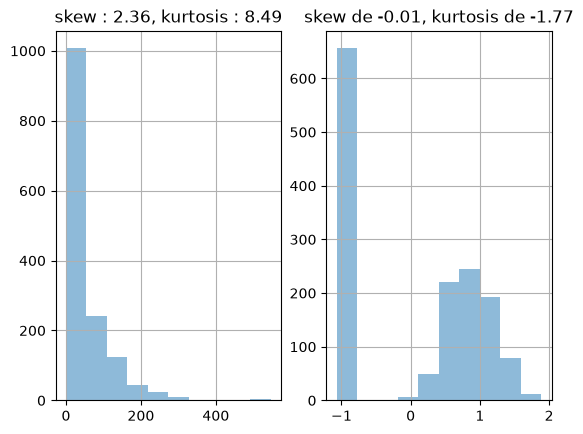

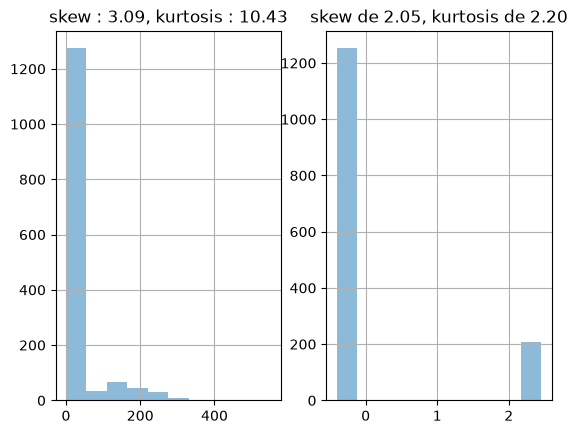

Skew trop élevé, à vérifier :3SsnPorch


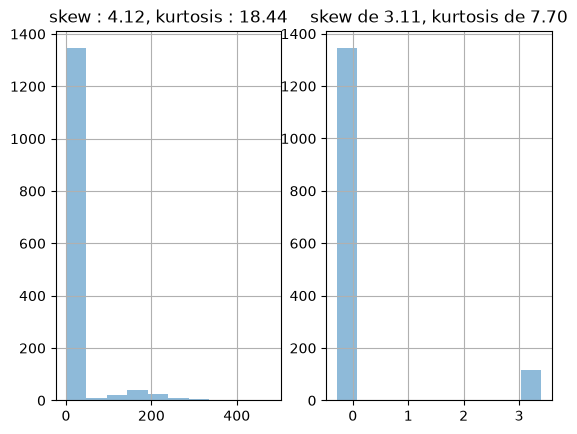

Skew trop élevé, à vérifier :PoolArea
Skew trop élevé, à vérifier :MiscVal


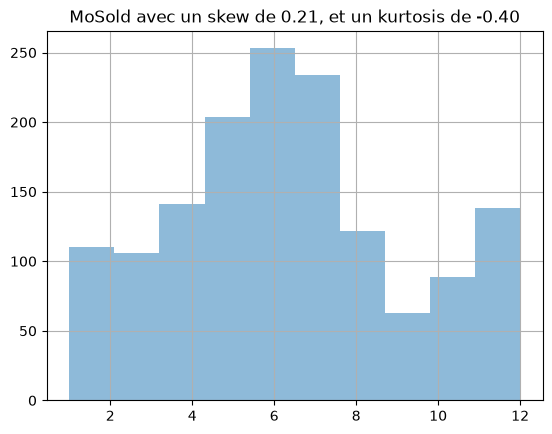

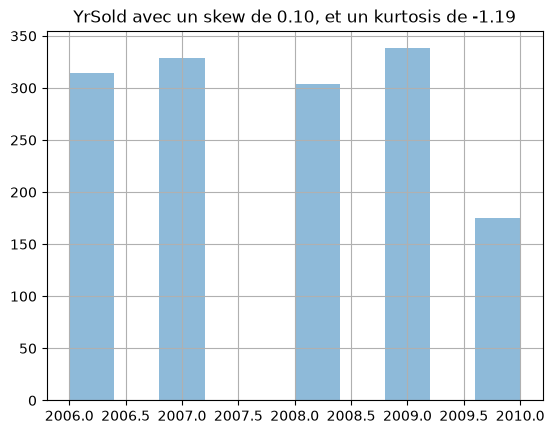

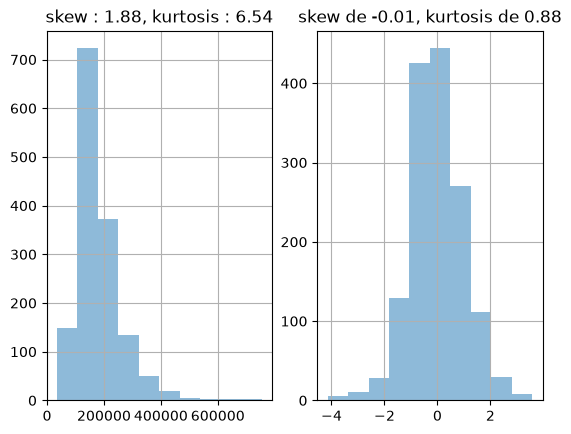

Skew trop élevé, à vérifier :Pool


In [19]:
power_transformer = PowerTransformer(method='yeo-johnson')
cat_cols = df_train.select_dtypes(include='number').columns
cat_cols = cat_cols.drop(['OverallCond', 'OverallQual'])

for c in cat_cols:
    if abs(df_train[c].skew()) > 1:
        if abs(df_train[c].skew())<10:
            fig, ax = plt.subplots(1, 2)
            df_train[c].hist(alpha=0.5, label=c, ax=ax[0])
            ax[0].set_title(f'skew : {df_train[c].skew():.2f}, kurtosis : {df_train[c].kurtosis():.2f}')

            df_train[[c]] = power_transformer.fit_transform(df_train[[c]])

            df_train[c].hist(alpha=0.5, label=c, ax=ax[1])
            ax[1].set_title(f'skew de {df_train[c].skew():.2f}, kurtosis de {df_train[c].kurtosis():.2f}')
        if abs(df_train[c].skew())>10:
            print(f"Skew trop élevé, à vérifier :{c}")
    else:
        fig, ax = plt.subplots()
        df_train[c].hist(alpha=0.5, label=c, ax=ax)
        ax.set_title(f'{c} avec un skew de {df_train[c].skew():.2f}, et un kurtosis de {df_train[c].kurtosis():.2f}')
    plt.show()

In [20]:
from scipy.stats import f_oneway

global_mean = df_train['LotFrontage'].mean()
cat_cols = df_train.select_dtypes(exclude='number').columns

a=[]
b=[]
for c in cat_cols:
    grouped = df_train.groupby(c)['LotFrontage']
    means = grouped.mean()
    counts = grouped.count()

    ss_inter = (counts * (means - global_mean)**2).sum()
    ss_tot = ((df_train['LotFrontage'].dropna() - global_mean)**2).sum()

    groups = [group.dropna() for name, group in df_train.groupby(c)['LotFrontage']]
    f_stat, p_value = f_oneway(*groups)
    eta2 = ss_inter / ss_tot
    a.append(eta2)
    b.append(c)

Sig=pd.DataFrame({'Category':b,'eta2':a})
Sig=Sig.sort_values(by='eta2',ascending=False)
Sig


/tmp/ipykernel_131595/2251381858.py:17: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = f_oneway(*groups)
/tmp/ipykernel_131595/2251381858.py:17: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = f_oneway(*groups)
/tmp/ipykernel_131595/2251381858.py:17: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = f_oneway(*groups)


,Category,eta2
74,BldgType_Twnhs,2.094168e-01
21,MSZoning_RL,1.598883e-01
75,BldgType_TwnhsE,1.487188e-01
22,MSZoning_RM,1.412061e-01
34,Neighborhood_BrDale,9.854366e-02
...,...,...
1,Utilities,4.806810e-35
90,RoofMatl_Metal,4.806810e-35
87,RoofStyle_Shed,4.806810e-35
69,Condition2_RRAe,4.806810e-35


In [22]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(random_state=42)


df_train_imputer = df_train.select_dtypes(include=["number","bool"])


df_train = pd.DataFrame(
    imputer.fit_transform(df_train_imputer),
    columns=df_train_imputer.columns,
    index=df_train_imputer.index
)

df_train['LotFrontage'].isna().sum()

np.int64(0)

In [ ]:
df_train.isna().sum().sort_values(ascending=False)

Id                  0
MSSubClass          0
LotFrontage         0
LotArea             0
OverallQual         0
                   ..
FireplaceQu_Fa      0
FireplaceQu_Gd      0
FireplaceQu_None    0
FireplaceQu_Po      0
FireplaceQu_TA      0
Length: 104, dtype: int64